<a href="https://colab.research.google.com/github/yelle15/fuelcast/blob/main/machine-learning/GasModel2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPORT MODULES AND MODELS
1. import pandas and other models

In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC, SVR
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


# Phase 1 Data Preprocessing
1. load the dataset
2. removal of null values, replacement of null values, conversion of data types,



In [46]:
data = pd.read_csv('/content/sea_fuel_prices_2020_2026 - Sheet1.csv')

data['date'] = pd.to_datetime(data['date'])

data = data.sort_values(['country', 'date'])

data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['day'] = data['date'].dt.day

country_le = LabelEncoder()
income_le = LabelEncoder()
subsidy_le = LabelEncoder()

data['country_id'] = country_le.fit_transform(data['country'])
data['income_id'] = income_le.fit_transform(data['income_level'])
data['subsidy_id'] = subsidy_le.fit_transform(data['subsidy_level'])

print("Missing values per column:\n", data.isnull().sum())

Missing values per column:
 date                0
country             0
income_level        0
subsidy_level       0
petrol_usd_liter    0
diesel_usd_liter    0
lpg_usd_liter       0
brent_crude_usd     0
tax_percentage      0
year                0
month               0
day                 0
country_id          0
income_id           0
subsidy_id          0
dtype: int64


# Phase 2 Feature Engineering
1. scaling of features (maybe use StandardScaler but it will be determined)
2. addition of features


In [47]:
data['petrol_lag_1'] = data.groupby('country')['petrol_usd_liter'].shift(1)
data['brent_lag_1'] = data.groupby('country')['brent_crude_usd'].shift(1)

data = data.dropna()

features = ['country_id', 'income_id', 'subsidy_id', 'year', 'month', 'petrol_lag_1', 'brent_lag_1', 'tax_percentage']
X_raw = data[features]
y = data['petrol_usd_liter'].values

numeric_to_poly = ['petrol_lag_1', 'brent_lag_1', 'tax_percentage']
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_poly_raw = poly.fit_transform(X_raw[numeric_to_poly])
poly_cols = poly.get_feature_names_out(numeric_to_poly)

X_categorical = data[['country_id', 'income_id', 'subsidy_id', 'year', 'month']].reset_index(drop=True)
X_poly_df = pd.DataFrame(X_poly_raw, columns=poly_cols).reset_index(drop=True)
X_combined = pd.concat([X_categorical, X_poly_df], axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)
X_final = pd.DataFrame(X_scaled, columns=X_combined.columns)

print(f"Original features: {X.shape[1]}")
print(f"Features after engineering: {X_train_ready.shape[1]}")
print("\nNew features include:", [col for col in X_train_ready.columns if "^2" in col or " " in col][:5])

Original features: 8
Features after engineering: 14

New features include: ['petrol_lag_1^2', 'petrol_lag_1 brent_lag_1', 'petrol_lag_1 tax_percentage', 'brent_lag_1^2', 'brent_lag_1 tax_percentage']


# Phase 3 - Descriptive Analysis and Visualization
1. frequency Distribution
2. Trends overtime
3. Categorical Comparison
4. relationships and correlations

--- Descriptive Statistics ---
      petrol_usd_liter  brent_crude_usd  tax_percentage
mean          1.776981       106.812025       21.793208
std           1.332141        18.869086       15.156272
var           1.774599       356.042389      229.712584
mode          0.618000       130.000000       22.500000


/tmp/ipykernel_5341/767956500.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_prices.index, y=avg_prices.values, palette='viridis')


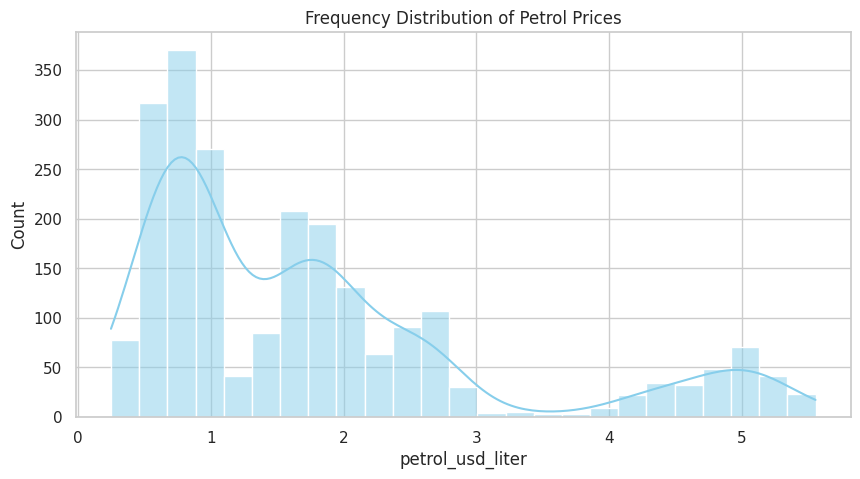

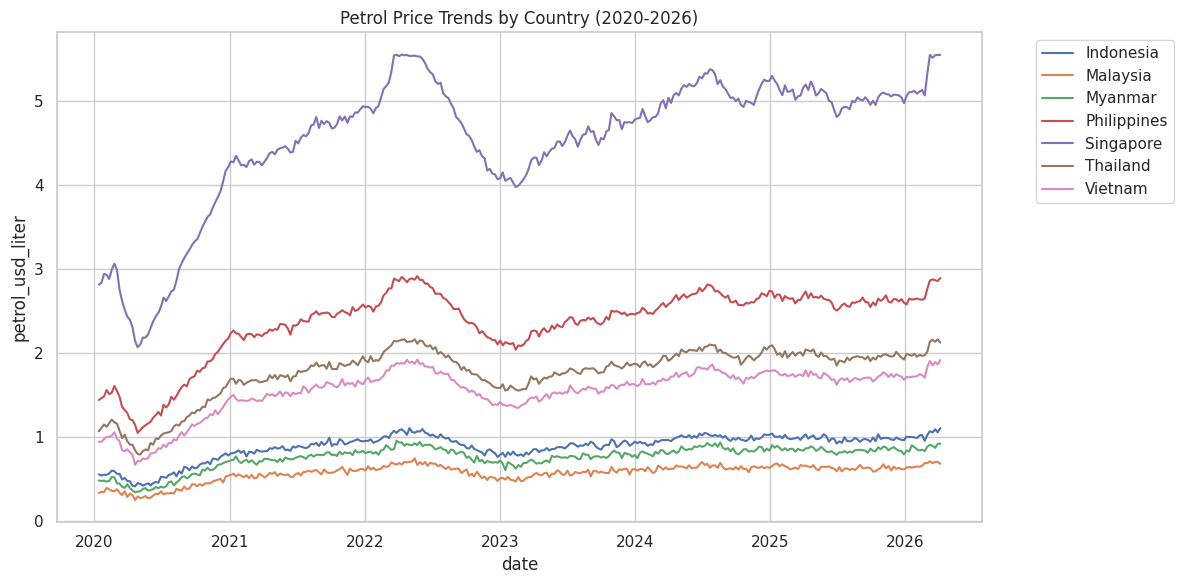

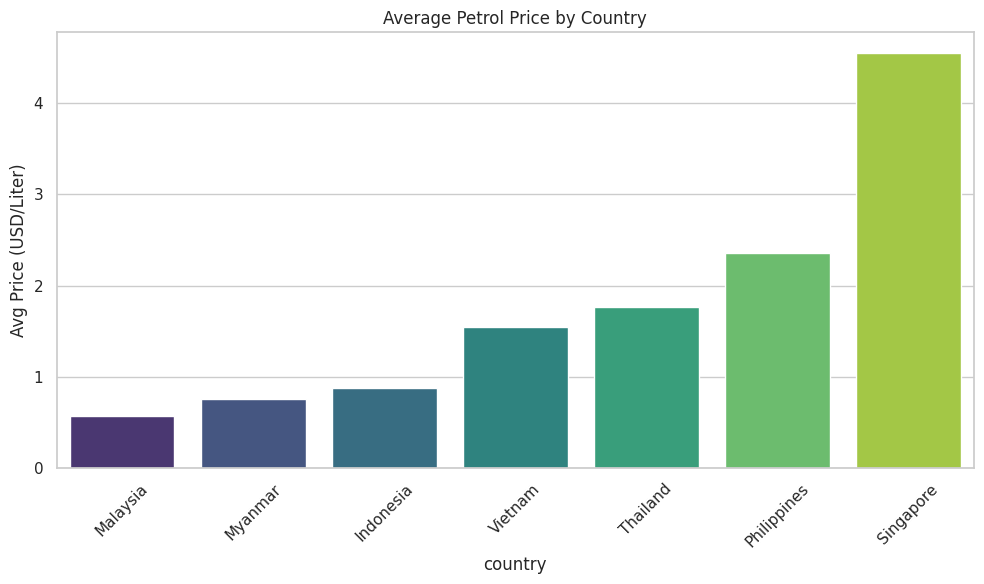

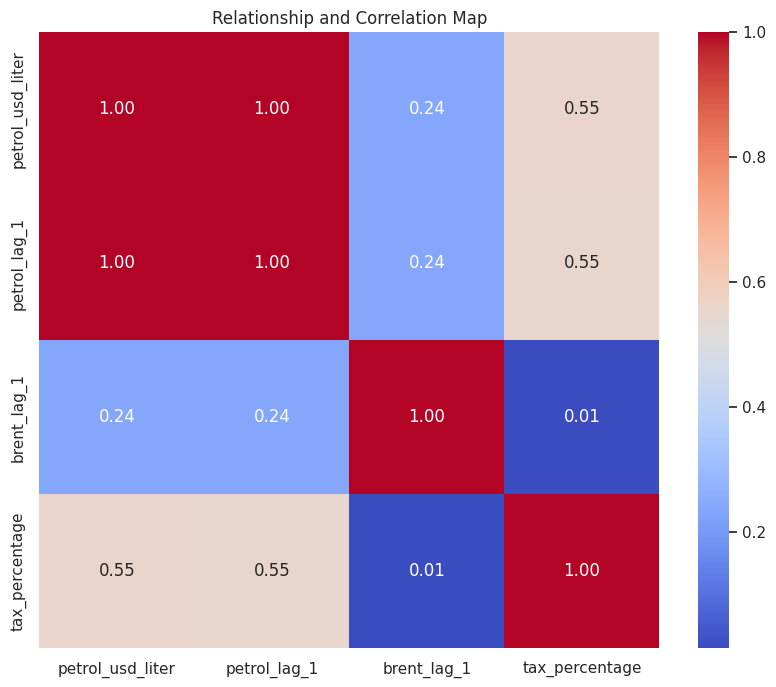

In [48]:
# 1. Descriptive Analysis
# Calculating Mean, Mode, Variance, and Std Dev
num_cols_analysis = ['petrol_usd_liter', 'brent_crude_usd', 'tax_percentage']
stats = data[num_cols_analysis].agg(['mean', 'std', 'var'])

# Calculate Mode separately (as it can return multiple values)
modes = data[num_cols_analysis].mode().iloc[0]
stats.loc['mode'] = modes

print("--- Descriptive Statistics ---")
print(stats)

# 2. Visualizations
sns.set(style="whitegrid")

# (1) Frequency and Distribution
plt.figure(figsize=(10, 5))
sns.histplot(data['petrol_usd_liter'], kde=True, color='skyblue')
plt.title('Frequency Distribution of Petrol Prices')
plt.savefig('frequency_distribution.png')

# (2) Trends over Time (Using Names for 'hue')
plt.figure(figsize=(12, 6))
sns.lineplot(data=data, x='date', y='petrol_usd_liter', hue='country')
plt.title('Petrol Price Trends by Country (2020-2026)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('trends_over_time.png')

# (3) Categorical Comparisons (Bar graph of average price per country)
plt.figure(figsize=(10, 6))
avg_prices = data.groupby('country')['petrol_usd_liter'].mean().sort_values()
sns.barplot(x=avg_prices.index, y=avg_prices.values, palette='viridis')
plt.title('Average Petrol Price by Country')
plt.ylabel('Avg Price (USD/Liter)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('categorical_comparison.png')

# (4) Relationship and Correlations
plt.figure(figsize=(10, 8))
# Correlate target with key predictors
corr_data = data[['petrol_usd_liter', 'petrol_lag_1', 'brent_lag_1', 'tax_percentage']]
sns.heatmap(corr_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Relationship and Correlation Map')
plt.savefig('correlation_heatmap.png')

plt.show()

# Phase 4 - Algorithm
1. Decision Trees (Bagging)
2. Boosting (XGBoost)
3. SVM
4. Logistic Regression

--- Model Performance Comparison ---
                             RMSE  R2 Score       MAE
Linear Regression        0.035406  0.986154  0.028405
Boosting (XGBoost)       0.053049  0.968917  0.043129
Bagging (Random Forest)  0.053688  0.968164  0.043873
SVM (SVR)                0.080794  0.927902  0.063716


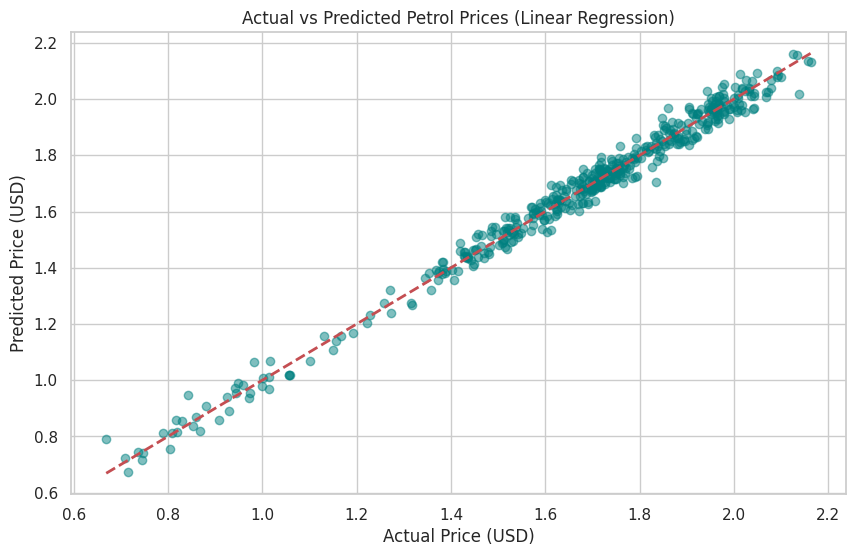

In [52]:
y_values = y

train_mask = data['date'] < '2025-01-01'
test_mask = data['date'] >= '2025-01-01'

X_train = X_train_ready.iloc[:sum(train_mask)]
X_test = X_train_ready.iloc[sum(train_mask):]
y_train = y_values[:sum(train_mask)]
y_test = y_values[sum(train_mask):]

models = {
    "Bagging (Random Forest)": RandomForestRegressor(n_estimators=200, random_state=42),
    "Boosting (XGBoost)": XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42),
    "SVM (SVR)": SVR(kernel='rbf', C=1.0, epsilon=0.01),
    "Linear Regression": LinearRegression()
}

model_performance = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    model_performance[name] = {"RMSE": rmse, "R2 Score": r2, "MAE": mae}

performance_df = pd.DataFrame(model_performance).T.sort_values(by="RMSE")
print("--- Model Performance Comparison ---")
print(performance_df)

best_model_name = performance_df.index[0]
best_model = models[best_model_name]
y_final_pred = best_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_final_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Actual vs Predicted Petrol Prices ({best_model_name})')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.savefig('model_results_scatter.png')
plt.show()